## Labo Week 1 : Intro numpy en Pandas
**Data Science 2025-2026**

---

#### **Deel 1 : numpy, lineaire algebra en matplotlib**





Om te rekenen met matrices is de numpy module aangewezen wegens de efficiente manier waarop array operaties zonder loops afgehandeld kunnen worden (vectorization). 
**Een numpy array is een ndarray, waarmee je _n-dimensionele matrices_ kan aanmaken.**

De __[Quickstart van NumPy](https://docs.scipy.org/doc/numpy/user/quickstart.html#quickstart-shape-manipulation)__ kan je steeds raadplegen.




__Oefening 1: opwarmer numpy__

* Definieer een klassieke Python-lijst met de gehele getallen van 1 t.e.m.48
* Maak hiervan een 1 dimensionele NumPy-array
* Maak hiervan een 2 dimensionele 6x8 matrix door gebruik te maken van de reshape operatie
* Print van deze 6x8 matrix: het aantal dimensies, de dimensies (= shape) zelf en het datatype van de elementen
* Maak op basis van deze 6x8 matrix een nieuwe 6x8 matrix door elk element te kwadrateren
* Gebruik slicing om
   * de __laatste__ rij weer te geven
   * van de eerste 2 kolommen de __laatste__ 2 rijen weer te geven
   * alle __even__ rijen en kolommen weer te geven
* Toon de booleaanse matrix die aangeeft of de elementen even zijn
* Gebruik deze booleaanse matrix om alle even elementen op 0 te zetten


In [7]:
import numpy as np
npArray = np.array(range(1, 49))

bigNpArray = npArray.reshape(6,8)

print(len(bigNpArray), bigNpArray.ndim, bigNpArray.shape, bigNpArray.dtype)

newArray = bigNpArray ** 2
print(newArray[-1])
print(newArray[-2:, :2])
print(newArray[1::2, 1::2])

even = newArray % 2 == 0
print(even)
newArray[even] = 0

print(newArray)


6 2 (6, 8) int64
[1681 1764 1849 1936 2025 2116 2209 2304]
[[1089 1156]
 [1681 1764]]
[[ 100  144  196  256]
 [ 676  784  900 1024]
 [1764 1936 2116 2304]]
[[False  True False  True False  True False  True]
 [False  True False  True False  True False  True]
 [False  True False  True False  True False  True]
 [False  True False  True False  True False  True]
 [False  True False  True False  True False  True]
 [False  True False  True False  True False  True]]
[[   1    0    9    0   25    0   49    0]
 [  81    0  121    0  169    0  225    0]
 [ 289    0  361    0  441    0  529    0]
 [ 625    0  729    0  841    0  961    0]
 [1089    0 1225    0 1369    0 1521    0]
 [1681    0 1849    0 2025    0 2209    0]]


__Oefening 2__: **shape, type en dimensie van een array**

* Genereer een 1 dimensionele numpy array op basis van random getallen in het interval $[1,200]$. De shape is de volgende: $(4,)$.
* Genereer een 2 dimensionele numpy array met random getallen in het interval $[1,200]$. De shape is de volgende: $(4,5)$.
* Genereer een 3 dimensionele numpy array met random getallen in het interval $[1,200]$. De shape is de volgende: $(3,3,3)$
    

In [8]:
rg = np.random.default_rng()

print(np.array(np.floor(rg.random([4,]) * 200)))# kon ook met import random random.randint(1, 200) for i in range(4) ipv. rg.random([4,])
print(np.array(np.floor(rg.random([4,5]) * 200)))
print(np.array(np.floor(rg.random([3,3,3]) * 200)))

[126. 141.  53. 162.]
[[146. 152.  41.  72.  57.]
 [130.  90.  20. 113.  24.]
 [ 87. 145.  35.  16.  21.]
 [127.  95.  22. 174.  48.]]
[[[188. 157. 120.]
  [ 95. 127. 198.]
  [ 31.  40.  15.]]

 [[ 27.   9.  26.]
  [109.  44. 179.]
  [ 38. 145.  29.]]

 [[161. 130.  60.]
  [  8.  32. 121.]
  [125. 150.  38.]]]


 __Oefening3:__ **Vermenigvuldiging en inprodukt van arrays**

In plaats van traage for-loops te gebruiken, voert NumPy berekeningen uit op het niveau van de processor (met zogenaamde SIMD-instructies). Gebruik daarom altijd de ingebouwde NumPy functies zoals `np.sum()` in plaats van de standaard Python `sum()`. De NumPy variant is geoptimaliseerd in C en vele malen sneller op grote datasets.

**Broadcasting**: NumPy kan operaties uitvoeren op arrays van verschillende groottes (onder bepaalde voorwaarden).

Definieer 
$$x = \begin{bmatrix}
2  \\
4 
\end{bmatrix}$$

en 

$$ y = \begin{bmatrix}
3 & 4 \\
5 & -1
\end{bmatrix}$$


- Ga na of de shape van x = (2,1) en die van y = (2,2)
- Bereken de puntsgewijze vermenigvuldiging van y met zichzelf
- Berkeken de puntsgewijze vermenigvuldiging van y en x (broadcasting!)
- Bereken het inprodukt van y en x
- Bereken het inprodukt van y met zichzelf

Ga na op papier of je dezelfde resultaten bekomt.


In [9]:
x = np.array([[2],[4]])
y = np.array([[3,4], [5,-1]])

print(x.shape == (2,1))
print(y.shape == (2,2))

print(y*y)
print(y*x)

print(y@x)
print(y@y)

True
True
[[ 9 16]
 [25  1]]
[[ 6  8]
 [20 -4]]
[[22]
 [ 6]]
[[29  8]
 [10 21]]


__Oefening 4:__ **Arrays van random getallen**

* Genereer een lijst met 2000 random elementen. Maak van deze lijst een numpy array (vector v) met shape (2000,). Verdubbel alle elementen uit de lijst en meet de tijd die hiervoor nodig m.b.v. de ipython magic functie %time. Doe hetzelfde voor de numpy vector v en vergelijk.

* Genereer een matrix A met shape (1000,1000). Genereer een matrix B met shape (1000,2000). Bereken het inprodukt A x B x v rechtstreeks. Wat is de tijd hiervoor nodig? (gebruik opnieuw ipython magic functie %time). Bereken nu eerst C = B x v en vervolgens A x C. Wat is de tijd hiervoor nodig? Vergelijk. 

In [10]:
list1 = rg.random(2000)
v = np.array(list1).reshape(2000,)
list1 * 2
print("Lijst random getallen:")
%time

v * 2

print("\nVector lijst:")
%time

A = np.array(rg.random(1000000)).reshape(1000,1000)
B = np.array(rg.random(2000000)).reshape(1000,2000)

C = B@v
A@C

print("\nBerekening:")
%time

Lijst random getallen:
CPU times: total: 0 ns
Wall time: 3.58 μs

Vector lijst:
CPU times: total: 0 ns
Wall time: 2.15 μs

Berekening:
CPU times: total: 0 ns
Wall time: 5.25 μs


__Oefening 5:__ **Oplossen van een stelsel van lineaire vergelijkingen adhv matrices**

Gegeven volgend stelsel. 

\begin{equation*}
\begin{array}{cc}
        2u + v &=& 5 \\
        4u + 2v &=& u 
\end{array}
\end{equation*}


Geef de matrixvoorstelling van dit stelsel. Los op m.b.v. numpy. 

- Zoek een oplossing via de inverse matrix. (zie slides : zoek eerst $\bf{A}, \bf{A}^{-1}$ en $\bf{b}$). 

- Het direct berekenen van een inverse matrix is numeriek instabiel en trager. Je kan daarom beter de $solve$ methode gebruiken. `np.linalg.solve` gebruikt slimmere algoritmes (zoals LU-decompositie) die veel nauwkeuriger zijn voor grote matrices.

Check of je 2x dezelfde oplossing bekomt.


In [11]:
D = np.array([[2,1], [3,2]])
E = np.array([5,0])

DInv = np.linalg.inv(D)
print(DInv@E)

print(np.linalg.solve(D,E))

[ 10. -15.]
[ 10. -15.]


__Oefening 6:__ **Lineaire transformaties plotten**

Een lijn plot of x-y plot visualiseert 2 dimensionele datapunten $(x_i,y_i)$ die al dan niet verbonden zijn door een lijn. Op de horizontale as duid je de datapunten $x_i$ aan en trek je een recht door $x_i$ loodrecht op de horizontale as. Op de verticale as toon je de overeenkomstige datapunten $y_i$ aan en trek je een rechte loodrecht op de verticale as door $y_i$. Daar waar de loodrechten snijden bevinden zich de koppels $(x_i,y_i)$. De y-waarden zijn meestal, de overeenkomstige x-waarden waar een functie oplosgelaten is. Wanneer de koppels verbonden worden door een lijn, bekom je het visuele functieverloop van de functie.

Plot de twee rechten uit oefening 5. Ga na of het snijpunt van deze 2 rechten gelijk is aan het punt dat je als oplossing vond. 

Tip : Speel met kleuren en lijnestyles, zie : https://www.machinelearningplus.com/plots/matplotlib-line-plot/

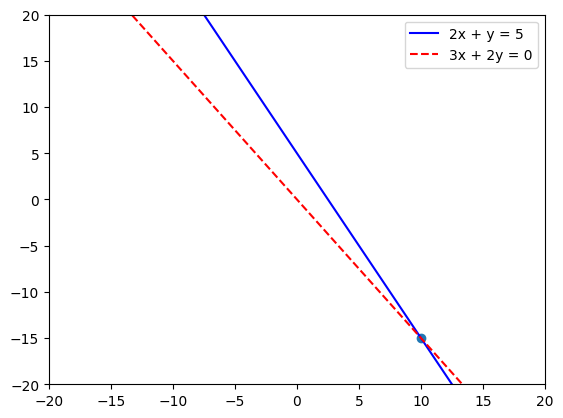

In [ ]:
import matplotlib.pyplot as plt

y1 = 5 - 2*x
y2 = -3/2*x

x = np.arange(-20, 20) # x = np.linspace(0, 10, 100)

plt.plot(x, y1, label="2x + y = 5", color="blue")
plt.plot(x, y2, label="3x + 2y = 0", color="red", linestyle="--")
plt.scatter(10, -15)
plt.legend()
plt.xlim(-20,20)
plt.ylim(-20,20)
plt.show()

__Oefening 7:__ **Lineaire transformaties van random punten**

* Gebruik de $numpy.random$ module voor het genereren van 4 random xy- coördinaten (volgens een normale verdeling). 

* Deze 4 coördinaten vormen de hoekpunten van een vierhoek. Plot de lijnen van deze figuur.

* Transformeer vervolgens deze figuur via volgende lineaire transformatie :

\begin{equation*}
\bf{A} = 
\begin{bmatrix}
-3 & 1 \\
1 & 5
\end{bmatrix}
\end{equation*}


*  Bereken de determinant van de matrix. (dit geeft je alvast informatie over het type transformatie.)

* Plot de getransformeerde figuur in een andere kleur

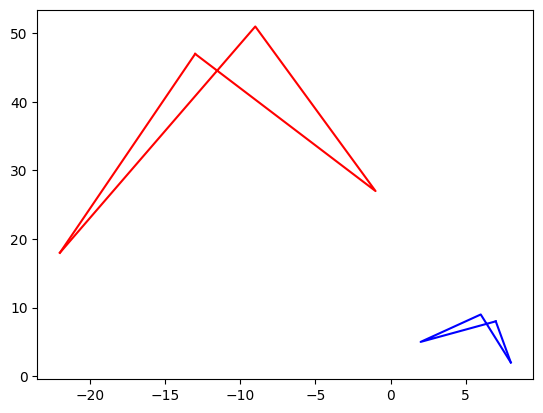

-16.000000000000007


In [19]:
import matplotlib.pyplot as plt

x = np.floor(rg.random(4)*10)
y = np.floor(rg.random(4)*10)

plt.plot(x,y, color="blue")
plt.plot([x[0], x[-1]], [y[0], y[-1]], color="blue")

A = np.array([[-3,1],[1,5]])
xy = np.column_stack((x, y))
transform = xy @ A

det = np.linalg.det(A)
x2 = transform[:,0]
y2 = transform[:,1]

plt.plot(x2,y2, color="red")
plt.plot([x2[0], x2[-1]], [y2[0], y2[-1]], color="red")
plt.show()

np.split
print(det)



__Oefening 8: De heatmap__

De np-matrix kan je rechtstreeks visualiseren met __[matplotlib's pcolor of imshow](https://matplotlib.org/gallery/images_contours_and_fields/pcolor_demo.html#sphx-glr-gallery-images-contours-and-fields-pcolor-demo-py)__  

*  Genereer een matrix A met shape (10,10). Genereer random getallen tussen 0 en 1000 uniform verdeeld. Plot deze matrix als een heatmap uit. Voeg een kleurschaal toe.
* Verifieer de waarden van de cellen die koud of heet zijn.


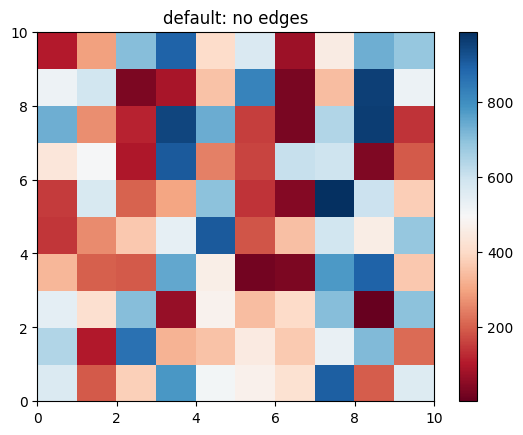

In [20]:
A = np.array(np.random.uniform(0,1000, 100)).reshape(10,10)

fig, (ax0) = plt.subplots(1,1)

c = ax0.pcolor(A, cmap='RdBu')
ax0.set_title('default: no edges')

fig.colorbar(c, ax=ax0)
plt.show()

# ??? niet getoond in les.

#### **Deel 2: Pandas**

Een Pandas Dataframe is een datastructuur om 2 dimensionele data met bijbehorende labels voor rijen en kolommen te bewaren. Je kan ze zeker vergelijken met SQL-tabellen maar de verwerking ervan en het gebruik is eenvoudiger en sneller.

Een Pandas Serie is een 1 dimensionale array met bijbehorend label. Ze vormen de basisblokken van een dataframe, dus bekijken we deze eerst.


__Oefening 9: Pandas Series basics__

**9.1**  Genereer een serie1 vertrekkende van een lijst. Maak een eerst een lijst aan met alle letters van het alfabet. Zet deze lijst om naar een serie. Druk de eerste en laatste elementen van de serie uit. Vraag apart de labels en de waarden van de serie op.

**9.2**  Genereer een serie2 vertrekkende van een numpy array. Maak eerst een numpy array met hierin de cijfers van 1 tot 26. Zet deze array om naar een serie. Druk de eerste en laatste elementen van de serie uit. Labels hoeven zeker niet numeriek te zijn. Gebruik nu hoofdletters van het alfabet als label/ index waarden voor serie2. 

**9.3** Genereer een serie3 vertrekkende van een dict. Maak eerst een dictionary met als key de cijfers van 1 tot 26 en als value de letters van het alfabet. Zet deze dict om naar een serie. Druk de eerste en laatste elementen van de serie uit. Vraag de shape en de dimensies op van deze serie en geef de index en data values van serie 3 een naam (name attribute).

**9.4** Selecteren en bewerken van elementen in een serie :

* geef alle elementen van serie1 die zich op index posities 0,4,8,14 en 20 bevinden

* geef alle klinkers uit serie1, doe dit via de `isin` membership functie

* geef alle elementen van serie2 die zich op het label 'M', 'N', 'O' en 'P' bevinden

* geef alle elementen van serie3 vanaf index positie 12

* geef alle elementen van serie1 die ook in serie 3 aanwezig zijn

* geef alle elementen van serie2 die niet in serie 3 aanwezig zijn

* verdubbel elke waarde van serie 2

* Sorteer de elementen van serie3 in omgekeerde volgorde van het label / index


In [21]:
import pandas as pd
import string

# 9.1
print("\n=== Oefening 1 ===")
letters = list(string.ascii_lowercase)
serie1 = pd.Series(letters)
print(serie1.iloc[0:1]) # of head en tail gebruiken
print(serie1.loc[0:0])

print(serie1.iloc[-1:])
print(serie1.iloc[25:])

# 9.2
print("\n=== Oefening 2 ===")
ints = range(1,27)
num = np.array(ints)
serie2 = pd.Series(num, index=letters)
print(serie2.iloc[0:1])
print(serie2.loc['a':'a'])

print(serie2.iloc[-1:])
print(serie2.loc['z':])

# 9.3
print("\n=== Oefening 3 ===")
d = dict()
for i in ints:
    d[i] = letters[i-1]
serie3 = pd.Series(d)
print(serie3.iloc[0:1])
print(serie3.iloc[-1:])
print(serie3.shape, serie3.ndim)

serie3.name = "Hier is de veranderde naam"
print(serie3.name)

# 9.4
print("\n=== Oefening 4 ===")
# geef alle elementen van serie1 die zich op index posities 0,4,8,14 en 20 bevinden
print(serie1.iloc[[0,4,8,14,20]])

# geef alle klinkers uit serie1, doe dit via de `isin` membership functie
klinkers = ['a', 'e', 'i', 'o', 'u']
print(serie1[serie1.isin(klinkers)])

# * geef alle elementen van serie2 die zich op het label 'M', 'N', 'O' en 'P' bevinden
print(serie2.loc[['m', 'n', 'o', 'p']])

# * geef alle elementen van serie3 vanaf index positie 12
print(serie3.iloc[12:])

# * geef alle elementen van serie1 die ook in serie 3 aanwezig zijn
print(serie1.isin(serie3))
print(serie1[serie1.isin(serie3)])

# * geef alle elementen van serie2 die niet in serie 3 aanwezig zijn
print(serie2[~serie2.isin(serie3)])

# * verdubbel elke waarde van serie 2
print(serie2 * 2)

# * Sorteer de elementen van serie3 in omgekeerde volgorde van het label / index
print(serie3.sort_index(ascending=False))


=== Oefening 1 ===
0    a
dtype: str
0    a
dtype: str
25    z
dtype: str
25    z
dtype: str

=== Oefening 2 ===
a    1
dtype: int64
a    1
dtype: int64
z    26
dtype: int64
z    26
dtype: int64

=== Oefening 3 ===
1    a
dtype: str
26    z
dtype: str
(26,) 1
Hier is de veranderde naam

=== Oefening 4 ===
0     a
4     e
8     i
14    o
20    u
dtype: str
0     a
4     e
8     i
14    o
20    u
dtype: str
m    13
n    14
o    15
p    16
dtype: int64
13    m
14    n
15    o
16    p
17    q
18    r
19    s
20    t
21    u
22    v
23    w
24    x
25    y
26    z
Name: Hier is de veranderde naam, dtype: str
0     True
1     True
2     True
3     True
4     True
5     True
6     True
7     True
8     True
9     True
10    True
11    True
12    True
13    True
14    True
15    True
16    True
17    True
18    True
19    True
20    True
21    True
22    True
23    True
24    True
25    True
dtype: bool
0     a
1     b
2     c
3     d
4     e
5     f
6     g
7     h
8     i
9     j
10    k
11

__Oefening 10: Pandas Dataframe basics__

**10.1** Maak volgende datastructuren aan :

- Een pandas serie met 20 stukken fruit random opgevuld uit dit lijstje : "apple, lemon, banana, kiwi, strawberry, pineapple". Uiteraard zal deze serie dubbels bevatten
    
- Een pandas serie met 20 random gewichten in g voor deze stukken fruit. Gebruik 1 van de numpy $random$ methodes om 20 random gewichten te genereren.
    
- Een dictionary met data over het vitamine C gehalte van deze stukken fruit. Per 100 gr zijn dit de vitamine C gehaltes van de stukken fruit.
     apple: 4.6 mg,  lemon: 53mg , banana: 8.7 mg, kiwi: 92.7 mg, strawberry : 58.8 mg, pineapple: 47,8 mg. 

**10.2** Maak een dataframe op basis van de 2 series. Vraag afzonderlijk de rij en kolom labels op. Vraag tevens dimensie, size en shape op.

**10.3** Gebruik zowel `.loc` als `.iloc` om volgende data uit de dataframe te selecteren :

- Selecteer alle data uit de kolom 'fruit'

- Selecteer alle data uit de rijen 5 t.e.m 8

- Selecteer alle rijen met even index

- Selecteer alleen de data uit de 'weights' kolom en dit voor de laatste 4 rijen.

**10.4** Voeg een extra kolom 'total_vitamines' toe aan je dataframe met het juiste vitamine C gehalte voor de gegeven hoeveelheid van een bepaalde fruitsoort. 

**10.5** Geef per soort fruit het gemiddeld gewicht en het gemiddeld aantal vitamines aanwezig in de dataset. 

**10.6** Verwijder alle rijen uit de tabel, die van type banaan zijn. Verwijder tenslotte ook de kolom 'weights' uit je tabel.

In [22]:
import random as r
# 10.1
keuzes = ["apple", "lemon", "banana", "kiwi", "strawberry", "pineapple"]

fruit = list()
for _ in range(20):
    fruit.append(r.choice(keuzes))

fruitSerie = pd.Series(fruit)

weightSerie = pd.Series(np.floor(np.random.random(20) * 1000))

vitaminC = {"apple": 4.6, "lemon": 53, "banana": 8.7, "kiwi": 92.7, "strawberry": 58.8, "pineapple": 47.8}

In [23]:
# 10.2
df = pd.DataFrame({'Fruit': fruitSerie, 'Weight': weightSerie})
print(df.columns, df.index, df.ndim, df.size, df.shape)

Index(['Fruit', 'Weight'], dtype='str') RangeIndex(start=0, stop=20, step=1) 2 40 (20, 2)


In [24]:
# 10.3
print(df.loc[:,'Fruit'])
print(df['Fruit'])
print(df.Fruit)
print(df.iloc[:,0])

print(df.iloc[5:9,:])
print(df.loc[5:8,:])

print(df.iloc[::2, :])
print(df.loc[::2,:])

print(df.loc[16,"Weight"])
print(df.iloc[-4,-1])


0     pineapple
1         apple
2         apple
3     pineapple
4     pineapple
5     pineapple
6         apple
7         lemon
8     pineapple
9         apple
10       banana
11    pineapple
12    pineapple
13    pineapple
14    pineapple
15         kiwi
16        lemon
17       banana
18    pineapple
19        lemon
Name: Fruit, dtype: str
0     pineapple
1         apple
2         apple
3     pineapple
4     pineapple
5     pineapple
6         apple
7         lemon
8     pineapple
9         apple
10       banana
11    pineapple
12    pineapple
13    pineapple
14    pineapple
15         kiwi
16        lemon
17       banana
18    pineapple
19        lemon
Name: Fruit, dtype: str
0     pineapple
1         apple
2         apple
3     pineapple
4     pineapple
5     pineapple
6         apple
7         lemon
8     pineapple
9         apple
10       banana
11    pineapple
12    pineapple
13    pineapple
14    pineapple
15         kiwi
16        lemon
17       banana
18    pineapple
19      

In [25]:
# 10.4
vitaminC_per_100g = df["Fruit"].map(vitaminC)
df["total_vitamins"] = vitaminC_per_100g * (df["Weight"] / 100)
print(df["total_vitamins"])

0     158.696
1       3.358
2       0.276
3     322.650
4     303.052
5     267.680
6      35.006
7     520.460
8     166.344
9       2.070
10     19.662
11    268.158
12    210.798
13    187.854
14    460.314
15    859.329
16     74.730
17     56.028
18    249.994
19    365.700
Name: total_vitamins, dtype: float64


In [26]:
# 10.5
print(df.groupby(["Fruit"]).mean())

               Weight  total_vitamins
Fruit                                
apple      221.250000       10.177500
banana     435.000000       37.845000
kiwi       927.000000      859.329000
lemon      604.333333      320.296667
pineapple  543.000000      259.554000


In [27]:
# **10.6** Verwijder alle rijen uit de tabel, die van type banaan zijn. Verwijder tenslotte ook de kolom 'weights' uit je tabel. 
# eerst alle indexen opvragen met een masker, dan droppen, inplace=True, dan reset index en drop kolom met naam
mask = df[df["Fruit"] == "banana"].index
df.drop(mask, inplace=True)
df.reset_index()
df.drop(columns="Weight", inplace=True)